# Creating Graphs from model results

In this notebook, first the model created by model.ipynb is imported and then the visualisations are created.

## importing requried packages

In [2]:
import linopy
import pypsa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

import cartopy
import cartopy.crs as ccrs

import networkx as nx

import atlite
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show
from rasterio.crs import CRS
import rasterio as rio

from pathlib import Path
import xarray as xr

## Importing the models

In [3]:
n = pypsa.Network("pypsa_model_n.nc") # the model without CO2 limitations
n_no_co2 = pypsa.Network("pypsa_model_n_no_co2.nc") # the model with CO2 limitation of 0

INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.0.7 available! (Current: 1.0.1)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks


In [4]:
n.objective / 1e9 # in Mrd. €

np.float64(7.256160463896301)

In [5]:
n_no_co2.objective / 1e9 # in Mrd. €

np.float64(25.11951110315625)

In [6]:
def _weights(net):
    """Snapshot weights for objective aggregation (hours per snapshot)."""
    w = net.snapshot_weightings["objective"]
    if isinstance(w, pd.Series):
        return w.reindex(net.snapshots).fillna(1.0)
    return pd.Series(1.0, index=net.snapshots)

def _energy_mwh(net, p_df):
    """Convert power time series (MW) to energy (MWh) using snapshot weights."""
    w = _weights(net)
    return p_df.mul(w, axis=0).sum(axis=0)  # MWh per asset/column

def _carrier_series(net, df, carrier_index):
    """Group columns of df by carrier_index (a Series mapping col -> carrier)."""
    # df: snapshots x assets
    return df.groupby(carrier_index, axis=1).sum()

def _get_opt_capacity(net, component):
    """Return p_nom_opt if exists, else p_nom."""
    comp = getattr(net, component)
    if "p_nom_opt" in comp.columns:
        return comp["p_nom_opt"].fillna(comp["p_nom"])
    return comp["p_nom"]

def _safe_plot_series(s, title, ylabel):
    ax = s.sort_values(ascending=False).plot(kind="bar", figsize=(10,4))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def _ensure_prices(net):
    """Return bus marginal prices time series (snapshots x buses)."""
    if hasattr(net, "buses_t") and "marginal_price" in net.buses_t:
        return net.buses_t.marginal_price
    raise ValueError("No bus prices found (buses_t.marginal_price). Did the optimisation compute prices?")

In [15]:
n.carriers[["color"]].head(20)

,color
name,
CCGT,red
oil,brown
nuclear,turquoise
hydro,blue
solar,gold
onwind,dodgerblue
offwind,aquamarine
battery storage,yellowgreen
hydrogen storage underground,magenta


### TOTAL SYSTEM COST SPLIT BY TECHNOLOGY

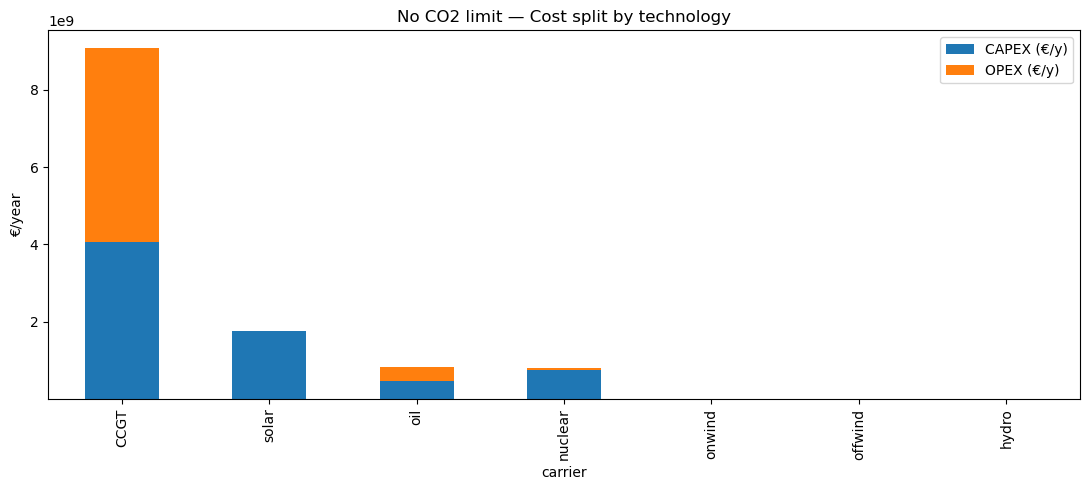

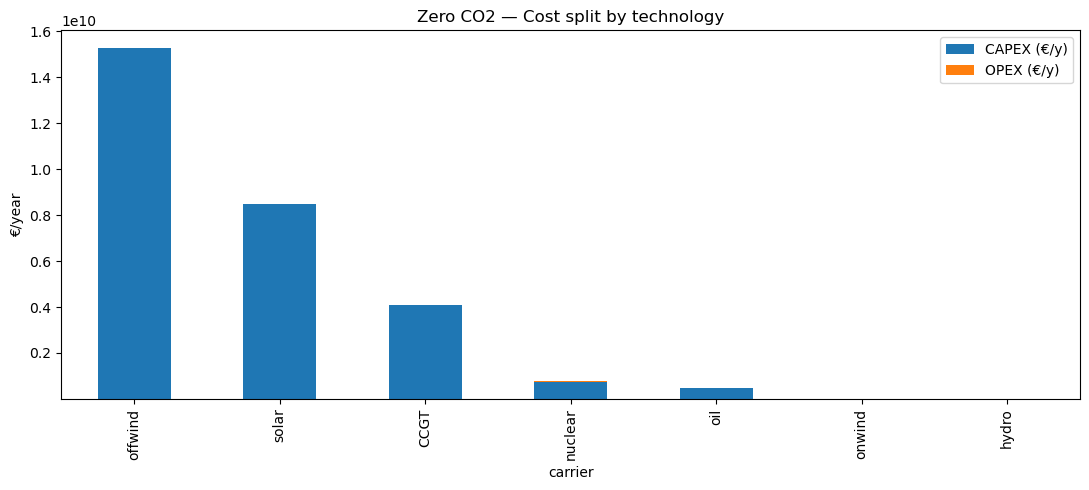

In [13]:

def plot_total_cost_split_by_tech_generators(net, title="Total system cost split by technology (Generators)"):
    #snapshot weights (hours per snapshot), I need to know this because I will need the information to be used in energy opex calculation 
    w = net.snapshot_weightings["objective"]
    if not isinstance(w, pd.Series):
        w = pd.Series(1.0, index=net.snapshots)
    w = w.reindex(net.snapshots).fillna(1.0)

    gens = net.generators.copy()

    #capacity used for capex, is the optimal capacity founded by the optimization
    if "p_nom_opt" in gens.columns:
        p_nom_used = gens["p_nom_opt"].fillna(gens["p_nom"])
    else:
        p_nom_used = gens["p_nom"]

    #CAPEX: only meaningful for extendable generators, becuase the other one have already been built so there is no capital cost 
    #extendable = gens.get("p_nom_extendable", False).fillna(False)
    capex = (gens.get("capital_cost", 0.0).fillna(0.0) * p_nom_used)#.where(extendable, 0.0)

    # OPEX: marginal_cost * energy
    # energy per generator = sum_t (p(t) * hours) 
    p = net.generators_t.p.reindex(net.snapshots).fillna(0.0)  # MW
    energy_mwh = p.mul(w, axis=0).sum(axis=0)                  # MWh per generator
    opex = energy_mwh * gens.get("marginal_cost", 0.0).fillna(0.0)  # €

    #group by technology (carrier)
    by_carrier = pd.DataFrame({
        "CAPEX (€/y)": capex,
        "OPEX (€/y)": opex
    }).groupby(gens["carrier"]).sum()

   
    by_carrier = by_carrier.loc[by_carrier.sum(axis=1).sort_values(ascending=False).index]

    ax = by_carrier.plot(kind="bar", stacked=True, figsize=(11,5))
    ax.set_title(title)
    ax.set_ylabel("€/year")
    plt.tight_layout()
    plt.show()

    return by_carrier

#use the function to plot 
cost_table_no_limit = plot_total_cost_split_by_tech_generators(n, title="No CO2 limit — Cost split by technology")
cost_table_zero_co2 = plot_total_cost_split_by_tech_generators(n_no_co2, title="Zero CO2 — Cost split by technology")


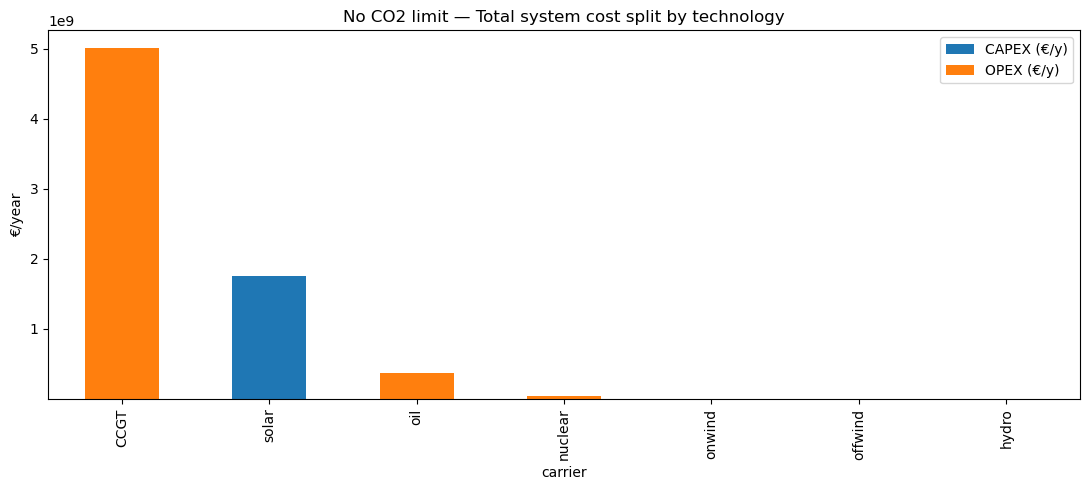

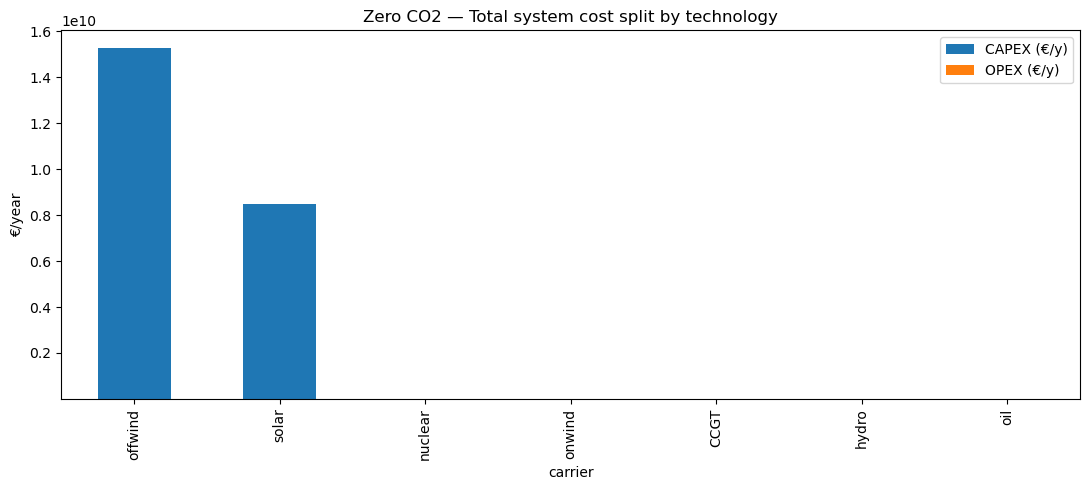

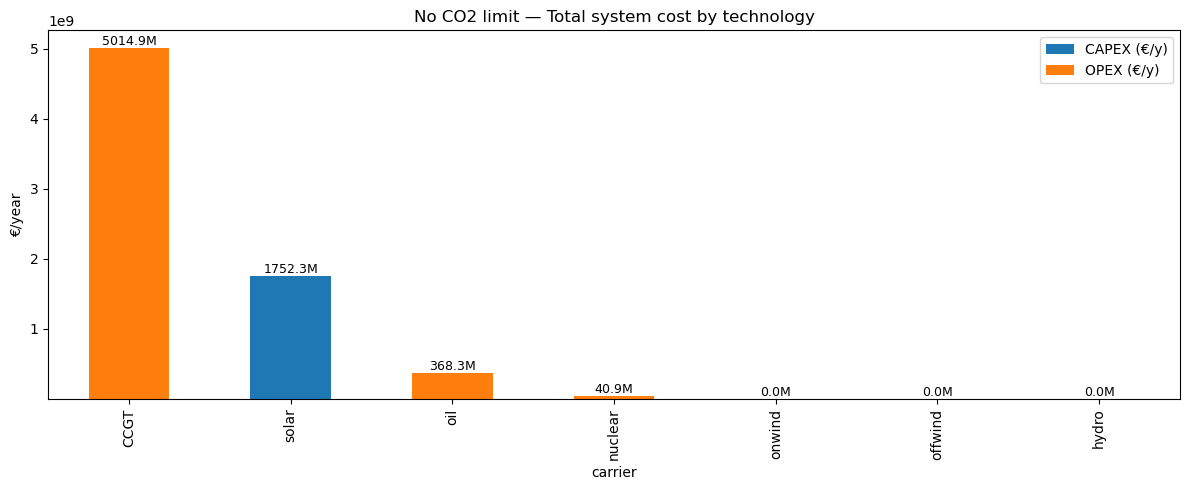

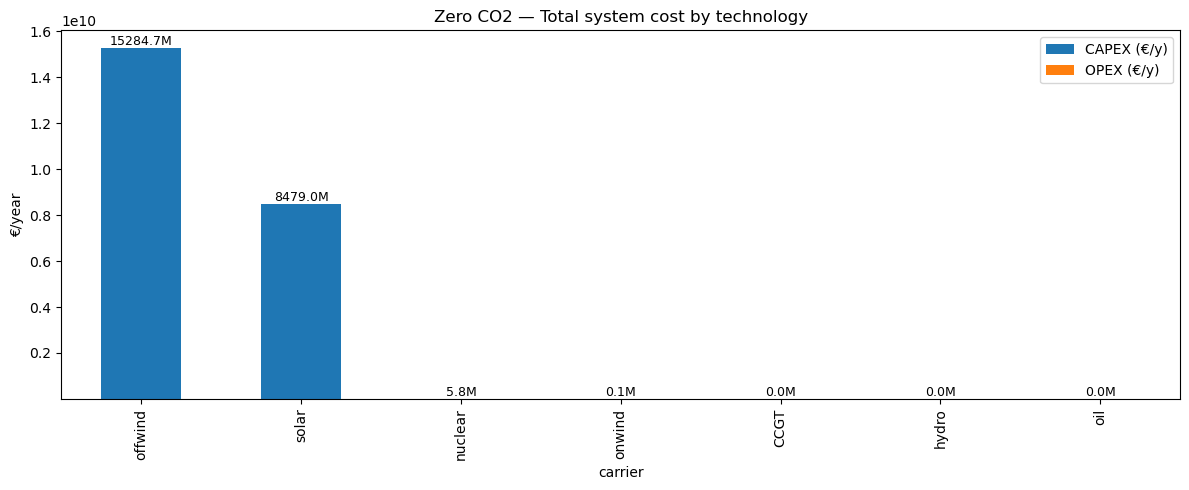

In [8]:


def plot_cost_split_with_labels(cost_df, title="Cost split by technology"):
    # cost_df: DataFrame with columns ["CAPEX (€/y)", "OPEX (€/y)"], index=carrier
    cost_df = cost_df.copy()
    cost_df["Total (€/y)"] = cost_df.sum(axis=1)
    cost_df = cost_df.loc[cost_df["Total (€/y)"].sort_values(ascending=False).index]

    ax = cost_df[["CAPEX (€/y)", "OPEX (€/y)"]].plot(kind="bar", stacked=True, figsize=(12,5))
    ax.set_title(title)
    ax.set_ylabel("€/year")
    plt.tight_layout()

    # add total labels above bars
    for i, total in enumerate(cost_df["Total (€/y)"].values):
        ax.text(i, total, f"{total/1e6:.1f}M", ha="center", va="bottom", fontsize=9, rotation=0)

    plt.show()


cost_no_limit = plot_total_cost_split_by_tech_generators(
    n,
    title="No CO2 limit — Total system cost split by technology"
)


cost_zero_co2 = plot_total_cost_split_by_tech_generators(
    n_no_co2,
    title="Zero CO2 — Total system cost split by technology"
)

plot_cost_split_with_labels(
    cost_no_limit,
    title="No CO2 limit — Total system cost by technology"
)


plot_cost_split_with_labels(
    cost_zero_co2,
    title="Zero CO2 — Total system cost by technology"
)



### Capacities built per technology (MW)

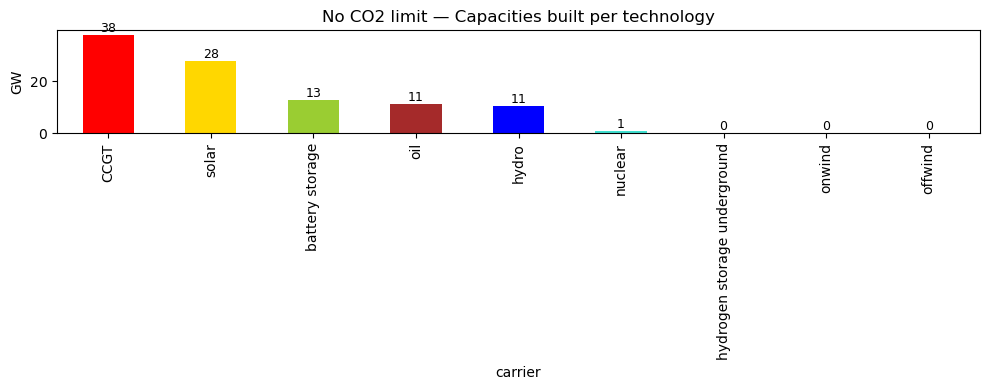

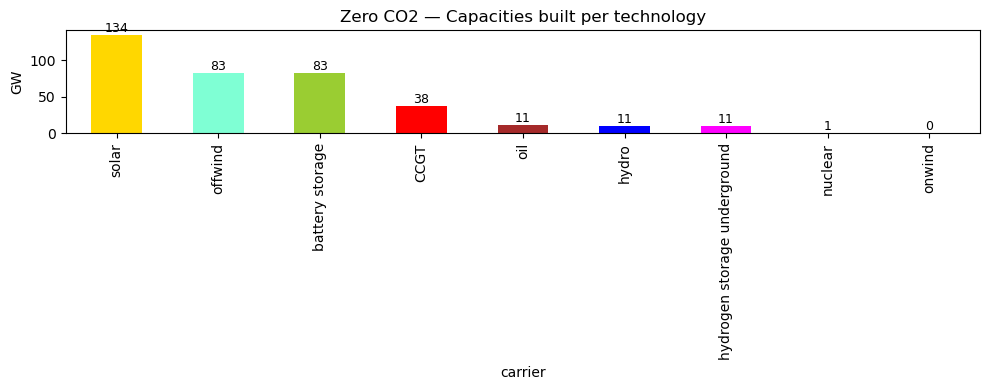

In [17]:
def plot_capacities_built(net, title_prefix=""):
    gen_cap = _get_opt_capacity(net, "generators")
    cap_by_car = gen_cap.groupby(net.generators["carrier"]).sum()

    if len(net.storage_units) > 0:
        su_cap = _get_opt_capacity(net, "storage_units")
        cap_by_car = cap_by_car.add(
            su_cap.groupby(net.storage_units["carrier"]).sum(),
            fill_value=0.0
        )

    cap_by_car = (cap_by_car.sort_values(ascending=False) / 1000.0)  # GW

    # colors aligned to carriers in the plot
    colors = net.carriers["color"].reindex(cap_by_car.index).fillna("grey").tolist()

    ax = cap_by_car.plot(kind="bar", color=colors, figsize=(10,4))
    ax.set_title(f"{title_prefix} Capacities built per technology")
    ax.set_ylabel("GW")
    plt.tight_layout()

    for i, value in enumerate(cap_by_car.values):
        ax.text(i, value, f"{value:.0f}", ha="center", va="bottom", fontsize=9)

    plt.show()
    return cap_by_car
cap_no_limit = plot_capacities_built(n, title_prefix="No CO2 limit —")
cap_zero_co2 = plot_capacities_built(n_no_co2, title_prefix="Zero CO2 —")



###  Electricity mix (energy by carrier, MWh)

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\3790644055.py:16: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



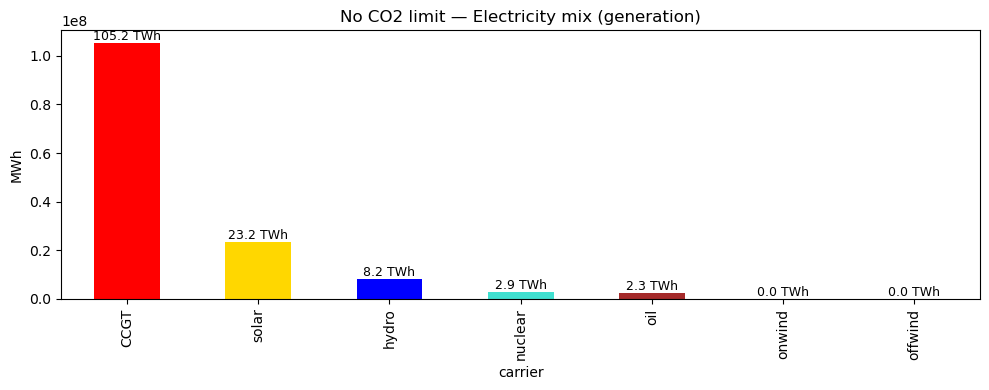

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\3790644055.py:16: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



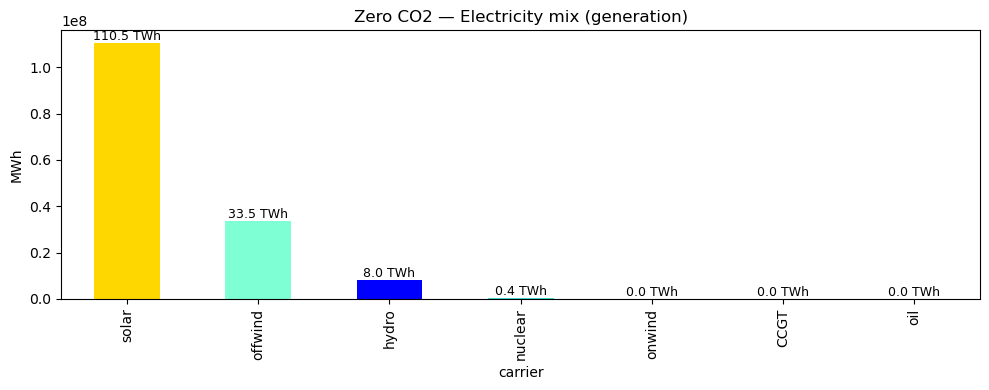

In [19]:
def plot_electricity_mix(net, title_prefix=""):
    if not (hasattr(net, "generators_t") and "p" in net.generators_t):
        raise ValueError("No generator dispatch found: generators_t.p")

    # Dispatch by generator (MW)
    gen_p = net.generators_t.p

    # Group by carrier (technology)
    gen_by_car = _carrier_series(net, gen_p, net.generators["carrier"])

    # Convert to annual energy (MWh)
    gen_energy_by_car = _energy_mwh(net, gen_by_car)

  
    gen_energy_by_car = gen_energy_by_car.sort_values(ascending=False)
    colors = net.carriers["color"].reindex(gen_energy_by_car.index).fillna("grey").tolist()

  
    ax = gen_energy_by_car.plot(kind="bar",color=colors, figsize=(10,4))
    ax.set_title(f"{title_prefix} Electricity mix (generation)")
    ax.set_ylabel("MWh")
    plt.tight_layout()

    
    for i, value in enumerate(gen_energy_by_car.values):
        ax.text(
            i,
            value,
            f"{value/1e6:.1f} TWh",   # change unit if you prefer
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.show()
    return gen_energy_by_car
    
mix_no_limit = plot_electricity_mix(n, title_prefix="No CO2 limit —")
mix_zero_co2 = plot_electricity_mix(n_no_co2, title_prefix="Zero CO2 —")


### CO2 shadow price (dual variable)

C:\Users\rebec\AppData\Local\Temp\ipykernel_22148\2788907695.py:13: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

C:\Users\rebec\AppData\Local\Temp\ipykernel_22148\2788907695.py:13: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



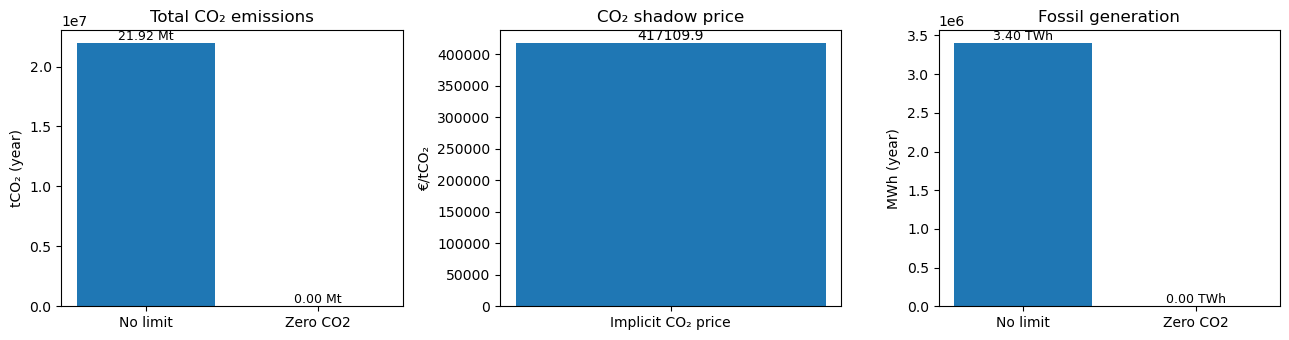

CO2 (no limit): 21923801.56267108 tCO2
CO2 (zero): 0.0 tCO2
mu: -417109.8977449347  -> implicit CO2 price = 417109.8977449347 €/tCO2


In [28]:

def snapshot_weights(net):
    w = net.snapshot_weightings["objective"]
    if not isinstance(w, pd.Series):
        w = pd.Series(1.0, index=net.snapshots)
    return w.reindex(net.snapshots).fillna(1.0)

def total_generation_by_carrier_mwh(net):
    w = snapshot_weights(net)
    gen_by_car = net.generators_t.p.groupby(net.generators.carrier, axis=1).sum()
    e_by_car = gen_by_car.mul(w, axis=0).sum(axis=0)  # MWh
    return e_by_car

def total_co2_tons(net):
    # total CO2 = sum_carrier( MWh * tCO2/MWh )
    e_by_car = total_generation_by_carrier_mwh(net)
    co2_factor = net.carriers["co2_emissions"].reindex(e_by_car.index).fillna(0.0)
    return float((e_by_car * co2_factor).sum())

def fossil_generation_mwh(net, fossil_carriers=("gas","oil","coal")):
    w = snapshot_weights(net)
    fossil_gens = net.generators.index[net.generators.carrier.isin(fossil_carriers)]
    if len(fossil_gens) == 0:
        return 0.0
    return float(net.generators_t.p[fossil_gens].mul(w, axis=0).sum().sum())

def co2_mu(net, constraint_name="CO2Limit"):
    if constraint_name not in net.global_constraints.index:
        return np.nan
    return float(net.global_constraints.loc[constraint_name, "mu"])

def plot_co2_dashboard(n_base, n_zero, constraint_name="CO2Limit"):
    # totals
    co2_base = total_co2_tons(n_base)
    co2_zero = total_co2_tons(n_zero)

    fossil_base = fossil_generation_mwh(n_base)
    fossil_zero = fossil_generation_mwh(n_zero)

    mu = co2_mu(n_zero, constraint_name=constraint_name)
    implicit_price = -mu  # interpret as €/tCO2 (sign convention)

    fig, ax = plt.subplots(1, 3, figsize=(13,3.5))

    # total CO2
    ax[0].bar(["No limit", "Zero CO2"], [co2_base, co2_zero])
    ax[0].set_title("Total CO₂ emissions")
    ax[0].set_ylabel("tCO₂ (year)")
    for i, v in enumerate([co2_base, co2_zero]):
        ax[0].text(i, v, f"{v/1e6:.2f} Mt", ha="center", va="bottom", fontsize=9)

    # implicit CO2 price
    ax[1].bar(["Implicit CO₂ price"], [implicit_price])
    ax[1].set_title("CO₂ shadow price")
    ax[1].set_ylabel("€/tCO₂")
    ax[1].text(0, implicit_price, f"{implicit_price:.1f}", ha="center", va="bottom", fontsize=10)

    # fossil energy
    ax[2].bar(["No limit", "Zero CO2"], [fossil_base, fossil_zero])
    ax[2].set_title("Fossil generation")
    ax[2].set_ylabel("MWh (year)")
    for i, v in enumerate([fossil_base, fossil_zero]):
        ax[2].text(i, v, f"{v/1e6:.2f} TWh", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("CO2 (no limit):", co2_base, "tCO2")
    print("CO2 (zero):", co2_zero, "tCO2")
    print("mu:", mu, " -> implicit CO2 price =", implicit_price, "€/tCO2")

# Run it:
plot_co2_dashboard(n, n_no_co2, constraint_name="CO2Limit")

#The CO₂ shadow price is a system-wide indicator
#and therefore not technology-specific. 
#It represents the implicit carbon price that would make 
#the zero-emission system cost-optimal, independent of which technologies emit CO₂.


### Price duration curves (system and per region)

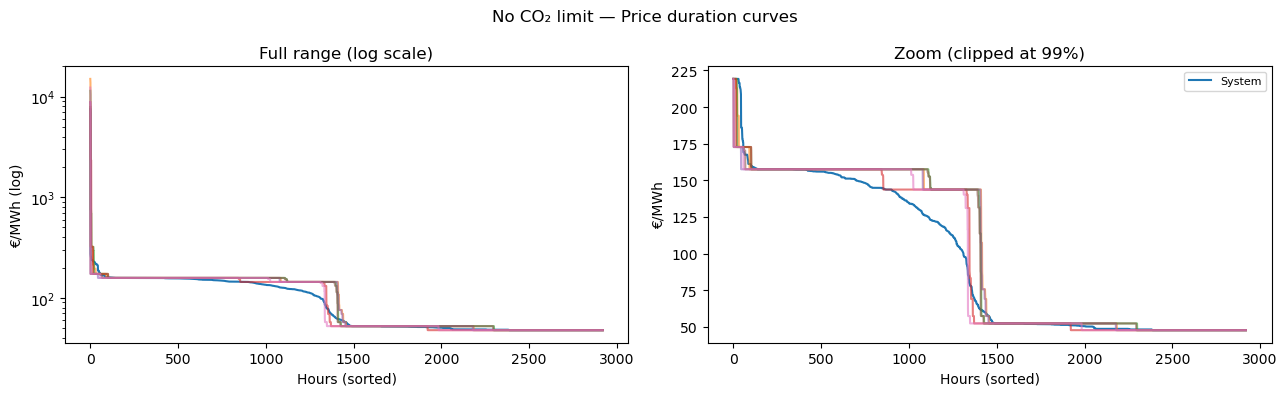

Clipping threshold (system): 219.24 €/MWh


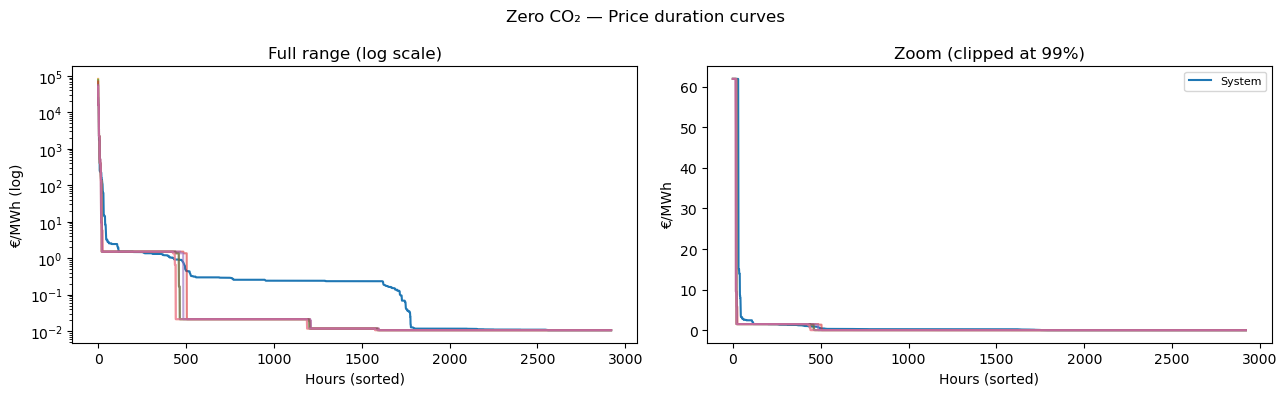

Clipping threshold (system): 61.91 €/MWh


In [33]:
def plot_price_duration_curves_report(net, title_prefix="", top_regions=6, clip_quantile=0.99):
    prices = _ensure_prices(net)

    if len(net.loads) > 0 and hasattr(net, "loads_t") and "p_set" in net.loads_t:
        load = net.loads_t.p_set
        load_by_bus = load.T.groupby(net.loads.bus).sum().T
        common = load_by_bus.columns.intersection(prices.columns)
        load_by_bus = load_by_bus[common]
        prices_use = prices[common]
        system_price = (prices_use * load_by_bus).sum(axis=1) / load_by_bus.sum(axis=1).replace(0, np.nan)
        system_price = system_price.fillna(prices_use.mean(axis=1))
    else:
        system_price = prices.mean(axis=1)

    avg_bus_price = prices.mean(axis=0).sort_values(ascending=False)
    regions_to_plot = list(avg_bus_price.head(top_regions).index)

    thr = system_price.quantile(clip_quantile)

    fig, ax = plt.subplots(1, 2, figsize=(13,4))

    # left: log scale full range
    ax[0].semilogy(np.sort(system_price.values)[::-1] + 1e-6, label="System")
    for b in regions_to_plot:
        ax[0].semilogy(np.sort(prices[b].values)[::-1] + 1e-6, alpha=0.6)
    ax[0].set_title("Full range (log scale)")
    ax[0].set_xlabel("Hours (sorted)")
    ax[0].set_ylabel("€/MWh (log)")

    # right: zoom (clipped)
    ax[1].plot(np.sort(np.clip(system_price.values, None, thr))[::-1], label="System")
    for b in regions_to_plot:
        ax[1].plot(np.sort(np.clip(prices[b].values, None, thr))[::-1], alpha=0.6)
    ax[1].set_title(f"Zoom (clipped at {clip_quantile:.0%})")
    ax[1].set_xlabel("Hours (sorted)")
    ax[1].set_ylabel("€/MWh")

    fig.suptitle(f"{title_prefix} Price duration curves")
    ax[1].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"Clipping threshold (system): {thr:.2f} €/MWh")

plot_price_duration_curves_report(
    n,
    title_prefix="No CO₂ limit —",
    top_regions=6,
    clip_quantile=0.99
)

plot_price_duration_curves_report(
    n_no_co2,
    title_prefix="Zero CO₂ —",
    top_regions=6,
    clip_quantile=0.99
)


#A small number of scarcity hours drives very high marginal prices,
#while the majority of hours has low prices due to abundant zero-marginal-cost renewable generation.


### Average electricity prices per region (€/MWh)

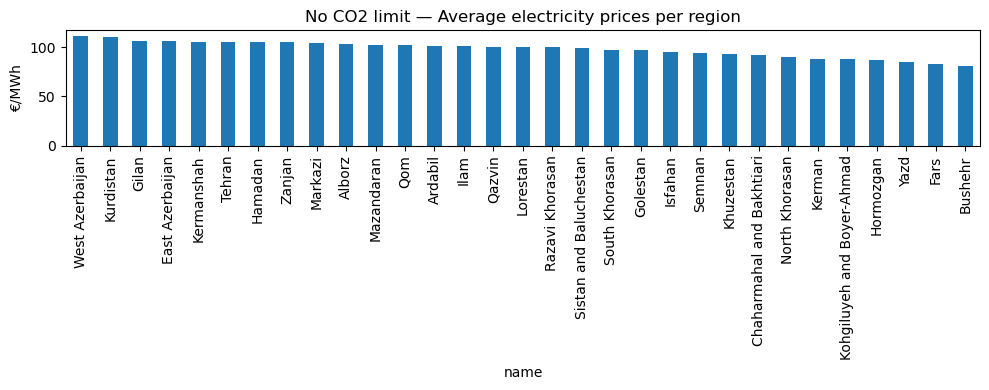

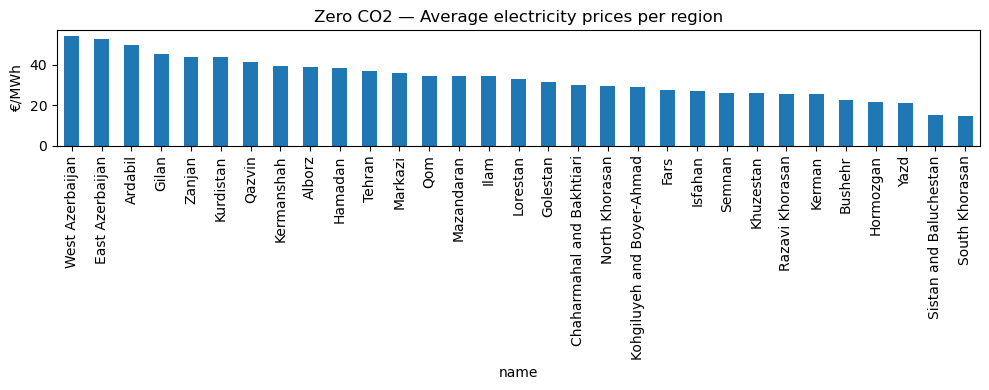

In [22]:
def plot_avg_prices_per_region(net, title_prefix=""):
    prices = _ensure_prices(net)
    avg = prices.mean(axis=0).sort_values(ascending=False)
    _safe_plot_series(avg, f"{title_prefix} Average electricity prices per region", "€/MWh")
    return avg
avgp_no_limit = plot_avg_prices_per_region(n, title_prefix="No CO2 limit —")
avgp_zero_co2 = plot_avg_prices_per_region(n_no_co2, title_prefix="Zero CO2 —")


### Curtailment rate (VRE)

In [26]:
def plot_curtailment(net, title_prefix="", vre_carriers=("solar", "onwind", "offwind")):
    if not (hasattr(net, "generators_t") and "p" in net.generators_t):
        raise ValueError("No generator dispatch found: generators_t.p")

    gens = net.generators.copy()
    vre = gens[gens["carrier"].isin(vre_carriers)].index
    if len(vre) == 0:
        print("No VRE generators found with carriers:", vre_carriers)
        return None

    p = net.generators_t.p[vre]  # MW
    cap = _get_opt_capacity(net, "generators").reindex(vre)  # MW

    # Available = p_max_pu * p_nom_opt
    if hasattr(net, "generators_t") and "p_max_pu" in net.generators_t:
        pmaxpu = net.generators_t.p_max_pu[vre]  # 0..1
    else:
        # fallback: use static p_max_pu if time series absent
        pmaxpu = pd.DataFrame(1.0, index=net.snapshots, columns=vre)

    available = pmaxpu.mul(cap, axis=1)  # MW
    w = _weights(net)
    avail_mwh = available.mul(w, axis=0).sum(axis=0)
    gen_mwh   = p.mul(w, axis=0).sum(axis=0)
    curtailed_mwh = (avail_mwh - gen_mwh).clip(lower=0.0)

    curtail_rate = (curtailed_mwh / avail_mwh.replace(0, np.nan)).fillna(0.0) * 100.0  # %
    curtail_rate = curtail_rate.where(curtail_rate >= 1e-6, 0.0)  # threshold in %
    # By carrier (weighted)
    curtail_by_car = curtail_rate.groupby(gens.loc[vre, "carrier"]).mean().sort_values(ascending=False)
    colors = net.carriers["color"].reindex(curtail_by_car.index).fillna("grey").tolist()
    _safe_plot_series(curtail_by_car, f"{title_prefix} Curtailment rate by VRE technology","%",color=colors,)
    return curtail_rate, curtail_by_car

    
curt_no_limit = plot_curtailment(n, title_prefix="No CO2 limit —")
curt_zero_co2 = plot_curtailment(n_no_co2, title_prefix="Zero CO2 —")


TypeError: _safe_plot_series() got an unexpected keyword argument 'color'

### Storage filling levels (SOC) throughout the year

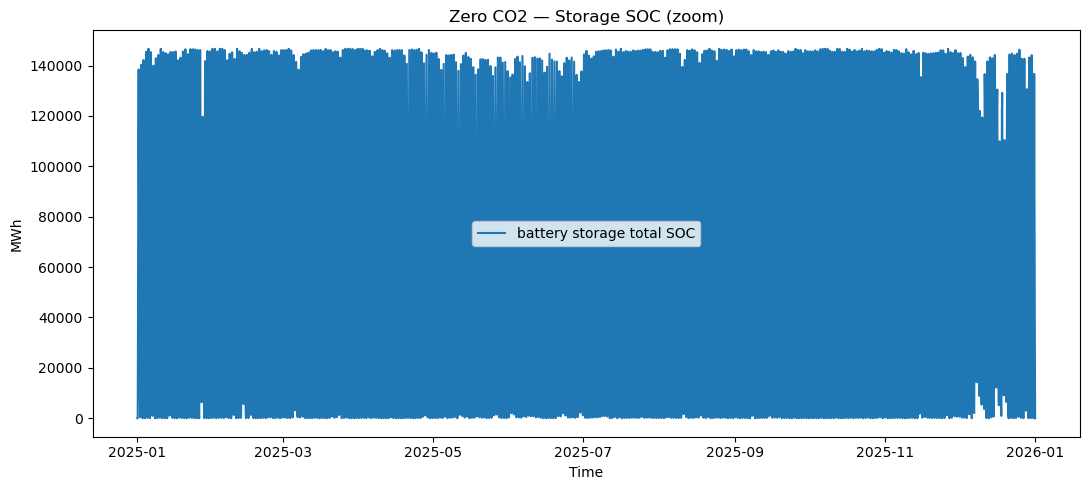

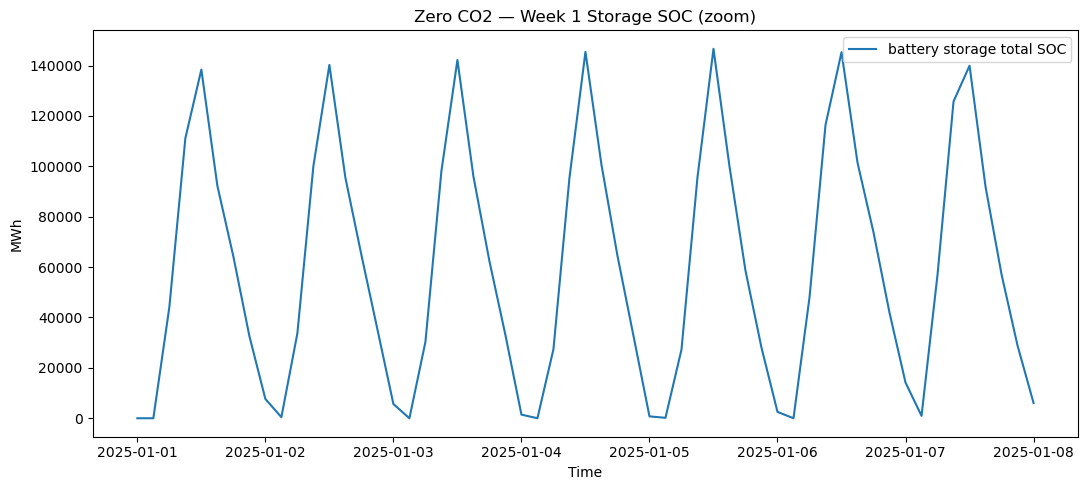

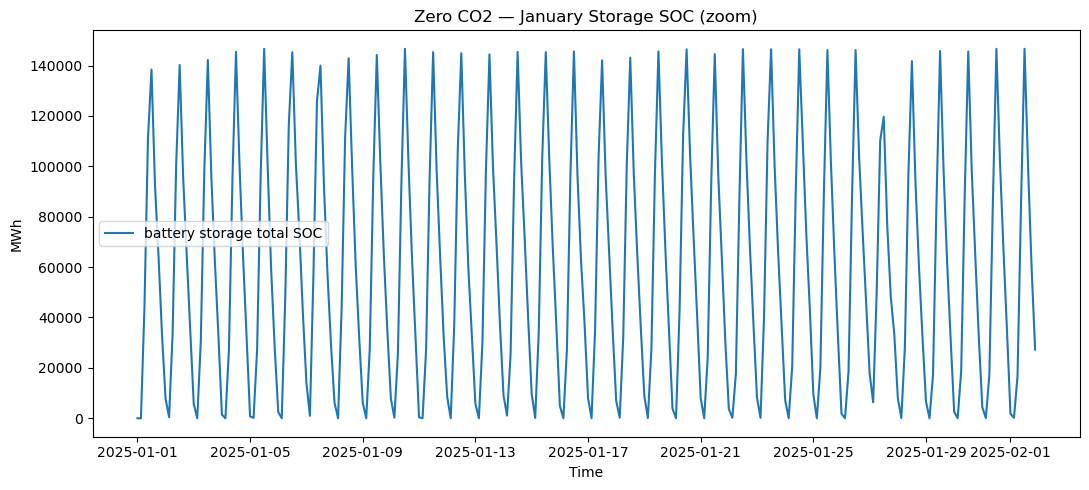

In [40]:
def plot_total_soc_by_carrier_zoom(
    net,
    title_prefix="",
    carriers=("battery storage","hydrogen storage underground"),
    start=None,
    end=None
):
    if not (hasattr(net, "storage_units_t") and "state_of_charge" in net.storage_units_t):
        print("No SOC data found.")
        return

    soc = net.storage_units_t.state_of_charge
    su  = net.storage_units.copy()

    # keep only built units
    if "p_nom_opt" in su.columns:
        su = su[su["p_nom_opt"].fillna(0.0) > 1e-3]

    if len(su) == 0:
        print(f"{title_prefix} No built storage units.")
        return

    # time slice
    if start is not None or end is not None:
        soc = soc.loc[start:end]

    plt.figure(figsize=(11,5))
    for c in carriers:
        units = su.index[su.carrier == c]
        if len(units) == 0:
            continue
        soc_total = soc[units].sum(axis=1)
        plt.plot(soc_total.index, soc_total.values, label=f"{c} total SOC")

    plt.title(f"{title_prefix} Storage SOC (zoom)")
    plt.ylabel("MWh")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()
    

plot_total_soc_by_carrier_zoom(
    n_no_co2,
    title_prefix="Zero CO2 —",
    carriers=["battery storage","hydrogen storage underground"]
)
plot_total_soc_by_carrier_zoom(
    n_no_co2,
    title_prefix="Zero CO2 — Week 1",
    start=n_no_co2.snapshots[0],
    end=n_no_co2.snapshots[0] + pd.Timedelta(days=7)
)
plot_total_soc_by_carrier_zoom(
    n_no_co2,
    title_prefix="Zero CO2 — January",
    start="2025-01-01",
    end="2025-02-01"
)



### Operation of the system for a selected week

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\3790644055.py:16: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\2467501731.py:22: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



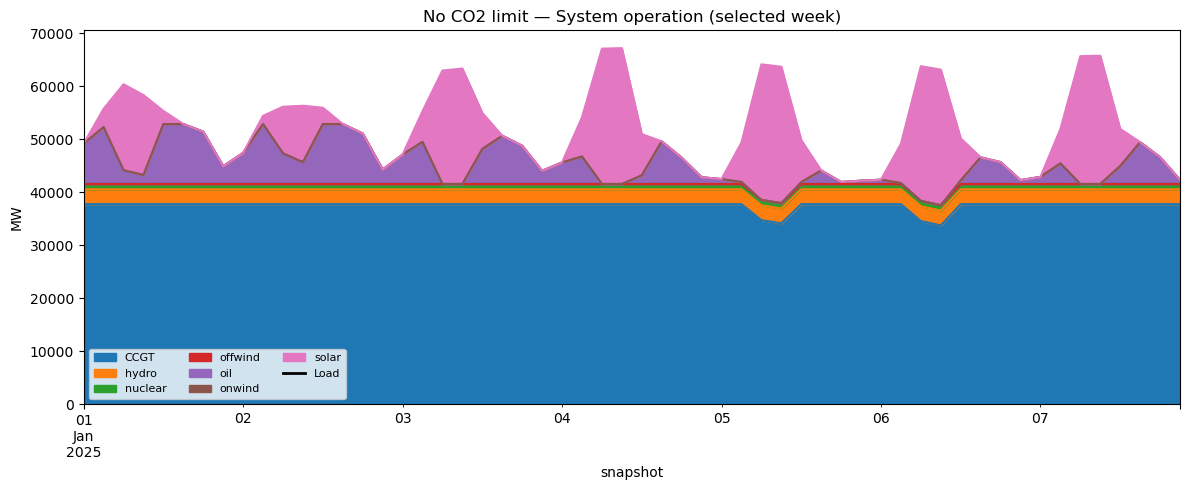

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\3790644055.py:16: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

C:\Users\rebec\AppData\Local\Temp\ipykernel_45508\2467501731.py:22: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



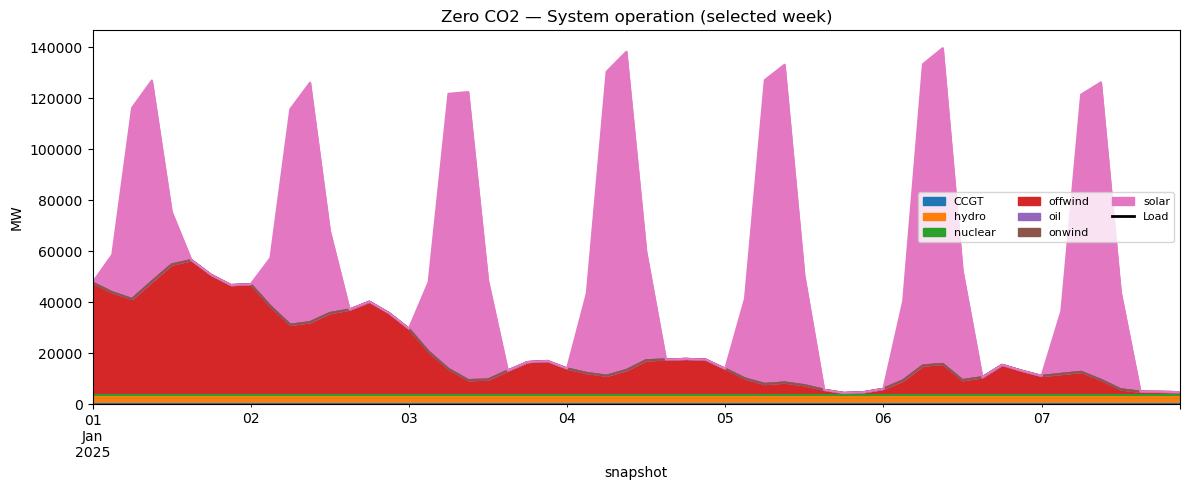

In [23]:
def plot_operation_week(net, start="2013-01-01", days=7, title_prefix=""):
    # pick window
    start = pd.Timestamp(start)
    end = start + pd.Timedelta(days=days)
    sns = net.snapshots[(net.snapshots >= start) & (net.snapshots < end)]
    if len(sns) == 0:
        # fallback: first week in snapshots
        sns = net.snapshots[:days*8]  # for 3-hourly, 8 steps/day

    # generation by carrier
    gen_by_car = _carrier_series(net, net.generators_t.p.loc[sns], net.generators["carrier"])

    # load total
    if hasattr(net, "loads_t") and "p_set" in net.loads_t:
        load_total = net.loads_t.p_set.loc[sns].sum(axis=1)
    else:
        load_total = None
    
    #colors = net.carriers["color"].reindex(gen_by_car.index).fillna("grey").tolist()
    ax = gen_by_car.plot(kind="area", stacked=True, figsize=(12,5))
    if load_total is not None:
        ax.plot(load_total.index, load_total.values, linewidth=2, label="Load", color="black")

    ax.set_title(f"{title_prefix} System operation (selected week)")
    ax.set_ylabel("MW")
    ax.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()
    
plot_operation_week(n, start=str(n.snapshots[0])[:10], days=7, title_prefix="No CO2 limit —")
plot_operation_week(n_no_co2, start=str(n_no_co2.snapshots[0])[:10], days=7, title_prefix="Zero CO2 —")